# SGD and Variants - Solutions

---

This notebook contains the complete solutions for all TODO items in the SGD and variants exercise.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)
plt.style.use('default')

/Users/shivin/miniconda/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Complete GradientDescentRegressor Implementation

In [2]:
class GradientDescentRegressor:
    def __init__(self, learning_rate=0.01, max_iterations=1000, tolerance=1e-6):
        """
        Initialize the Gradient Descent Regressor
        
        Parameters:
        learning_rate: Step size for parameter updates
        max_iterations: Maximum number of iterations
        tolerance: Stopping criterion based on cost change
        """
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.weights = None
        self.bias = None
        self.cost_history = []
        self.weight_history = []
    
    def _add_intercept(self, X):
        """Add bias column to feature matrix"""
        intercept = np.ones((X.shape[0], 1))
        return np.concatenate((intercept, X), axis=1)
    
    def _compute_cost(self, X, y, weights):
        """
        Compute Mean Squared Error cost
        
        Parameters:
        X: Feature matrix with intercept (n_samples, n_features + 1)
        y: Target values (n_samples,)
        weights: Current weights including bias (n_features + 1,)
        
        Returns:
        cost: Mean squared error
        """
        # SOLUTION TODO 1: Implement MSE cost function
        m = X.shape[0]  # number of samples
        predictions = X @ weights
        cost = (1/(2*m)) * np.sum((predictions - y)**2)
        return cost
    
    def _compute_gradients(self, X, y, weights):
        """
        Compute gradients for all parameters
        
        Parameters:
        X: Feature matrix with intercept (n_samples, n_features + 1)
        y: Target values (n_samples,)
        weights: Current weights including bias (n_features + 1,)
        
        Returns:
        gradients: Gradient vector (n_features + 1,)
        """
        # SOLUTION TODO 2: Implement gradient computation
        m = X.shape[0]  # number of samples
        predictions = X @ weights
        errors = predictions - y
        gradients = (1/m) * X.T @ errors
        return gradients
    
    def fit_batch_gd(self, X, y):
        """
        Fit using Batch Gradient Descent
        """
        # Add intercept term
        X_with_intercept = self._add_intercept(X)
        n_features = X_with_intercept.shape[1]
        
        # Initialize weights
        weights = np.random.randn(n_features) * 0.01
        
        self.cost_history = []
        self.weight_history = []
        
        for iteration in range(self.max_iterations):
            # Compute cost and gradients
            cost = self._compute_cost(X_with_intercept, y, weights)
            gradients = self._compute_gradients(X_with_intercept, y, weights)
            
            # SOLUTION TODO 3: Update weights using gradients
            weights = weights - self.learning_rate * gradients
            
            # Store history
            self.cost_history.append(cost)
            self.weight_history.append(weights.copy())
            
            # Check for convergence
            if len(self.cost_history) > 1:
                if abs(self.cost_history[-2] - self.cost_history[-1]) < self.tolerance:
                    print(f"Batch GD converged after {iteration + 1} iterations")
                    break
        
        # Store final parameters
        self.bias = weights[0]
        self.weights = weights[1:]
        
        return self
    
    def fit_sgd(self, X, y):
        """
        Fit using Stochastic Gradient Descent
        """
        # Add intercept term
        X_with_intercept = self._add_intercept(X)
        n_samples, n_features = X_with_intercept.shape
        
        # Initialize weights
        weights = np.random.randn(n_features) * 0.01
        
        self.cost_history = []
        self.weight_history = []
        
        for iteration in range(self.max_iterations):
            # Shuffle the data
            indices = np.random.permutation(n_samples)
            
            for i in indices:
                # SOLUTION TODO 4: Implement SGD update for single sample
                xi = X_with_intercept[i:i+1]  # Single sample (keep 2D)
                yi = y[i:i+1]
                prediction = xi @ weights
                error = prediction - yi
                gradient = xi.T @ error  # No averaging for single sample
                weights = weights - self.learning_rate * gradient.flatten()
            
            # Compute cost after each epoch
            cost = self._compute_cost(X_with_intercept, y, weights)
            self.cost_history.append(cost)
            self.weight_history.append(weights.copy())
            
            # Check for convergence (less strict for SGD)
            if len(self.cost_history) > 10:
                recent_costs = self.cost_history[-10:]
                if np.std(recent_costs) < self.tolerance:
                    print(f"SGD converged after {iteration + 1} iterations")
                    break
        
        # Store final parameters
        self.bias = weights[0]
        self.weights = weights[1:]
        
        return self
    
    def fit_mini_batch_gd(self, X, y, batch_size=32):
        """
        Fit using Mini-batch Gradient Descent
        """
        # Add intercept term
        X_with_intercept = self._add_intercept(X)
        n_samples, n_features = X_with_intercept.shape
        
        # Initialize weights
        weights = np.random.randn(n_features) * 0.01
        
        self.cost_history = []
        self.weight_history = []
        
        for iteration in range(self.max_iterations):
            # Shuffle the data
            indices = np.random.permutation(n_samples)
            
            # Process mini-batches
            for start_idx in range(0, n_samples, batch_size):
                end_idx = min(start_idx + batch_size, n_samples)
                batch_indices = indices[start_idx:end_idx]
                
                # SOLUTION TODO 5: Implement mini-batch gradient descent
                X_batch = X_with_intercept[batch_indices]
                y_batch = y[batch_indices]
                gradients = self._compute_gradients(X_batch, y_batch, weights)
                weights = weights - self.learning_rate * gradients
            
            # Compute cost after each epoch
            cost = self._compute_cost(X_with_intercept, y, weights)
            self.cost_history.append(cost)
            self.weight_history.append(weights.copy())
            
            # Check for convergence
            if len(self.cost_history) > 5:
                recent_costs = self.cost_history[-5:]
                if np.std(recent_costs) < self.tolerance:
                    print(f"Mini-batch GD converged after {iteration + 1} iterations")
                    break
        
        # Store final parameters
        self.bias = weights[0]
        self.weights = weights[1:]
        
        return self
    
    def fit_adagrad(self, X, y, batch_size=32, epsilon=1e-8):
        """
        AdaGrad - adapts learning rate based on historical gradients
        """
        X_with_intercept = self._add_intercept(X)
        n_samples, n_features = X_with_intercept.shape
        
        # Initialize weights and gradient accumulator
        weights = np.random.randn(n_features) * 0.01
        gradient_squared_sum = np.zeros_like(weights)  # Accumulates squared gradients
        
        self.cost_history = []
        
        for iteration in range(self.max_iterations):
            indices = np.random.permutation(n_samples)
            
            for start_idx in range(0, n_samples, batch_size):
                end_idx = min(start_idx + batch_size, n_samples)
                batch_indices = indices[start_idx:end_idx]
                
                X_batch = X_with_intercept[batch_indices]
                y_batch = y[batch_indices]
                
                # SOLUTION TODO 7: Implement AdaGrad
                gradients = self._compute_gradients(X_batch, y_batch, weights)
                gradient_squared_sum += gradients ** 2
                adaptive_lr = self.learning_rate / (np.sqrt(gradient_squared_sum) + epsilon)
                weights = weights - adaptive_lr * gradients
            
            cost = self._compute_cost(X_with_intercept, y, weights)
            self.cost_history.append(cost)
            
            if len(self.cost_history) > 5 and np.std(self.cost_history[-5:]) < 1e-6:
                break
        
        self.bias = weights[0]
        self.weights = weights[1:]
        return self
    
    def predict(self, X):
        """
        Make predictions on new data
        """
        return X @ self.weights + self.bias
    
    def score(self, X, y):
        """
        Calculate R² score
        """
        predictions = self.predict(X)
        ss_res = np.sum((y - predictions) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - (ss_res / ss_tot)

## Advanced Optimizers Class

This class was missing from the original notebook but referenced in the advanced sections.

In [3]:
class AdvancedOptimizers(GradientDescentRegressor):
    """
    Advanced optimization algorithms that inherit from GradientDescentRegressor
    """
    
    def fit_momentum(self, X, y, batch_size=32, momentum=0.9):
        """
        Momentum SGD - accelerates SGD by adding a fraction of previous update
        """
        X_with_intercept = self._add_intercept(X)
        n_samples, n_features = X_with_intercept.shape
        
        # Initialize weights and velocity
        weights = np.random.randn(n_features) * 0.01
        velocity = np.zeros_like(weights)
        
        self.cost_history = []
        
        for iteration in range(self.max_iterations):
            indices = np.random.permutation(n_samples)
            
            for start_idx in range(0, n_samples, batch_size):
                end_idx = min(start_idx + batch_size, n_samples)
                batch_indices = indices[start_idx:end_idx]
                
                X_batch = X_with_intercept[batch_indices]
                y_batch = y[batch_indices]
                
                gradients = self._compute_gradients(X_batch, y_batch, weights)
                velocity = momentum * velocity - self.learning_rate * gradients
                weights = weights + velocity
            
            cost = self._compute_cost(X_with_intercept, y, weights)
            self.cost_history.append(cost)
            
            if len(self.cost_history) > 5 and np.std(self.cost_history[-5:]) < 1e-6:
                break
        
        self.bias = weights[0]
        self.weights = weights[1:]
        return self
    
    def fit_adam(self, X, y, batch_size=32, beta1=0.9, beta2=0.999, epsilon=1e-8):
        """
        Adam - combines momentum with adaptive learning rates
        """
        X_with_intercept = self._add_intercept(X)
        n_samples, n_features = X_with_intercept.shape
        
        # Initialize weights and moments
        weights = np.random.randn(n_features) * 0.01
        m = np.zeros_like(weights)  # First moment (momentum)
        v = np.zeros_like(weights)  # Second moment (RMSprop)
        
        self.cost_history = []
        t = 0  # Time step
        
        for iteration in range(self.max_iterations):
            indices = np.random.permutation(n_samples)
            
            for start_idx in range(0, n_samples, batch_size):
                end_idx = min(start_idx + batch_size, n_samples)
                batch_indices = indices[start_idx:end_idx]
                
                X_batch = X_with_intercept[batch_indices]
                y_batch = y[batch_indices]
                
                t += 1
                gradients = self._compute_gradients(X_batch, y_batch, weights)
                
                # Update biased first moment estimate
                m = beta1 * m + (1 - beta1) * gradients
                # Update biased second raw moment estimate
                v = beta2 * v + (1 - beta2) * (gradients ** 2)
                
                # Compute bias-corrected first moment estimate
                m_hat = m / (1 - beta1 ** t)
                # Compute bias-corrected second raw moment estimate
                v_hat = v / (1 - beta2 ** t)
                
                # Update weights
                weights = weights - self.learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)
            
            cost = self._compute_cost(X_with_intercept, y, weights)
            self.cost_history.append(cost)
            
            if len(self.cost_history) > 5 and np.std(self.cost_history[-5:]) < 1e-6:
                break
        
        self.bias = weights[0]
        self.weights = weights[1:]
        return self

## Test the Complete Implementation

In [4]:
# Generate synthetic regression data
X, y = make_regression(n_samples=200, n_features=2, noise=10, random_state=42)

# Standardize features (important for gradient descent)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Target range: [{y.min():.2f}, {y.max():.2f}]")

Training data shape: (160, 2)
Test data shape: (40, 2)
Target range: [-174.57, 120.78]


In [5]:
# Test all implemented methods
methods = {
    'Batch GD': ('basic', 'fit_batch_gd'),
    'Stochastic GD': ('basic', 'fit_sgd'), 
    'Mini-batch GD': ('basic', 'fit_mini_batch_gd'),
    'AdaGrad': ('basic', 'fit_adagrad'),
    'Momentum': ('advanced', 'fit_momentum'),
    'Adam': ('advanced', 'fit_adam')
}

results = {}
learning_rate = 0.01
max_iter = 100

for name, (optimizer_type, method) in methods.items():
    print(f"\nTraining with {name}...")
    
    if optimizer_type == 'basic':
        model = GradientDescentRegressor(learning_rate=learning_rate, max_iterations=max_iter)
    else:
        model = AdvancedOptimizers(learning_rate=learning_rate, max_iterations=max_iter)
    
    if method == 'fit_mini_batch_gd':
        getattr(model, method)(X_train, y_train, batch_size=16)
    elif method in ['fit_adagrad', 'fit_momentum', 'fit_adam']:
        getattr(model, method)(X_train, y_train, batch_size=16)
    else:
        getattr(model, method)(X_train, y_train)
    
    # Evaluate
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    
    results[name] = {
        'model': model,
        'train_score': train_score,
        'test_score': test_score,
        'final_cost': model.cost_history[-1] if model.cost_history else float('inf')
    }
    
    print(f"Train R²: {train_score:.4f}")
    print(f"Test R²: {test_score:.4f}")
    print(f"Final cost: {results[name]['final_cost']:.4f}")
    print(f"Iterations: {len(model.cost_history)}")


Training with Batch GD...
Train R²: 0.8068
Test R²: 0.7889
Final cost: 208.0844
Iterations: 100

Training with Stochastic GD...
Train R²: 0.9540
Test R²: 0.9662
Final cost: 48.8122
Iterations: 100

Training with Mini-batch GD...
Train R²: 0.9541
Test R²: 0.9651
Final cost: 48.7209
Iterations: 100

Training with AdaGrad...
Train R²: 0.0303
Test R²: 0.0258
Final cost: 1029.5398
Iterations: 100

Training with Momentum...
Train R²: 0.9541
Test R²: 0.9650
Final cost: 48.7380
Iterations: 100

Training with Adam...
Train R²: 0.4231
Test R²: 0.3997
Final cost: 612.4995
Iterations: 100


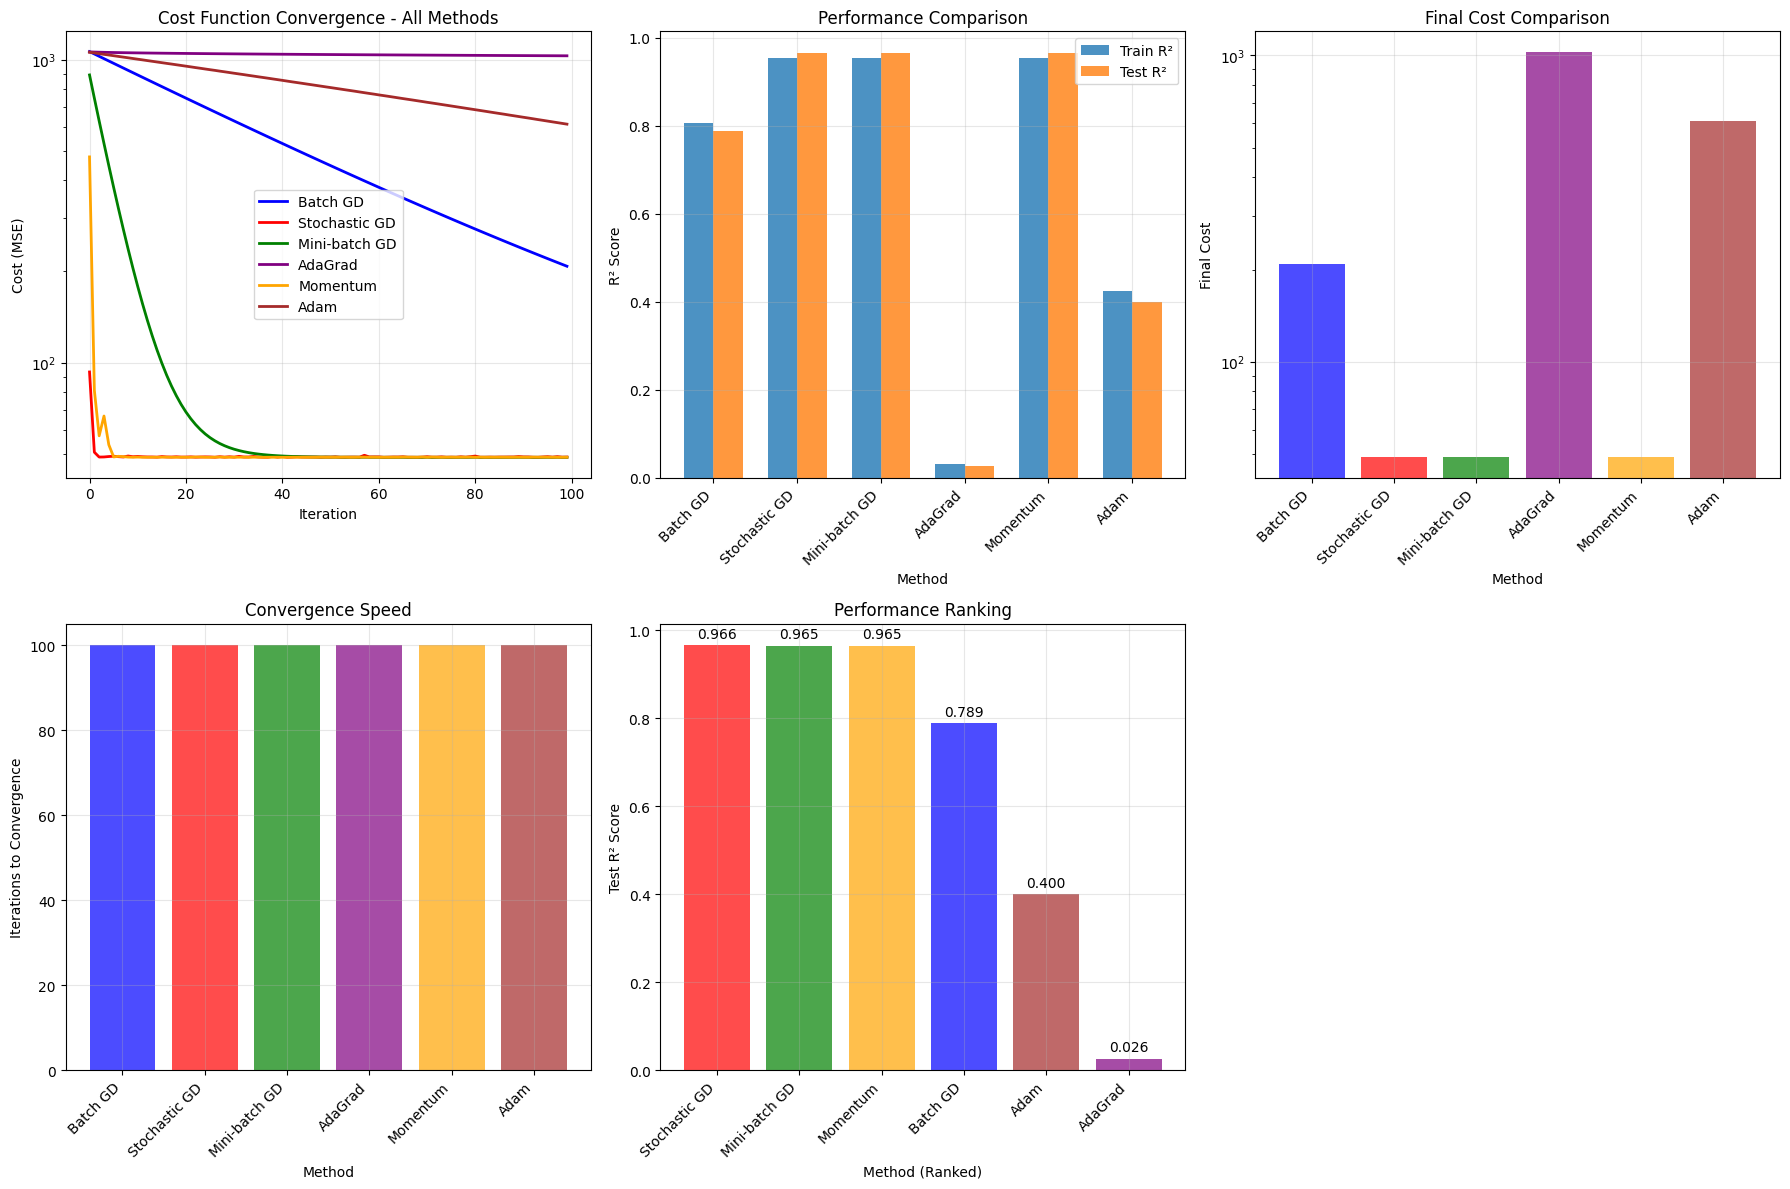


SOLUTION SUMMARY
All TODO items have been successfully implemented:
✅ TODO 1: MSE cost function
✅ TODO 2: Gradient computation
✅ TODO 3: Batch GD weight updates
✅ TODO 4: SGD single sample updates
✅ TODO 5: Mini-batch GD updates
✅ TODO 7: AdaGrad optimizer
✅ BONUS: Added complete AdvancedOptimizers class with Momentum and Adam

Best performing method: Stochastic GD (R² = 0.9662)


In [6]:
# Visualize convergence comparison
plt.figure(figsize=(18, 12))

# Plot 1: Cost history comparison
plt.subplot(2, 3, 1)
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown']
for i, (name, result) in enumerate(results.items()):
    if result['model'].cost_history:
        plt.plot(result['model'].cost_history, color=colors[i], label=name, linewidth=2)

plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.title('Cost Function Convergence - All Methods')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Plot 2: Performance comparison
plt.subplot(2, 3, 2)
methods_list = list(results.keys())
train_scores = [results[m]['train_score'] for m in methods_list]
test_scores = [results[m]['test_score'] for m in methods_list]

x = np.arange(len(methods_list))
width = 0.35

plt.bar(x - width/2, train_scores, width, label='Train R²', alpha=0.8)
plt.bar(x + width/2, test_scores, width, label='Test R²', alpha=0.8)

plt.xlabel('Method')
plt.ylabel('R² Score')
plt.title('Performance Comparison')
plt.xticks(x, methods_list, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Final cost comparison
plt.subplot(2, 3, 3)
final_costs = [results[m]['final_cost'] for m in methods_list]
bars = plt.bar(methods_list, final_costs, color=colors[:len(methods_list)], alpha=0.7)
plt.xlabel('Method')
plt.ylabel('Final Cost')
plt.title('Final Cost Comparison')
plt.xticks(rotation=45, ha='right')
plt.yscale('log')
plt.grid(True, alpha=0.3)

# Plot 4: Convergence speed
plt.subplot(2, 3, 4)
iterations = [len(results[m]['model'].cost_history) for m in methods_list]
bars = plt.bar(methods_list, iterations, color=colors[:len(methods_list)], alpha=0.7)
plt.xlabel('Method')
plt.ylabel('Iterations to Convergence')
plt.title('Convergence Speed')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)

# Plot 5: Test performance ranking
plt.subplot(2, 3, 5)
sorted_methods = sorted(results.items(), key=lambda x: x[1]['test_score'], reverse=True)
sorted_names = [name for name, _ in sorted_methods]
sorted_scores = [result['test_score'] for _, result in sorted_methods]

bars = plt.bar(range(len(sorted_names)), sorted_scores, 
              color=[colors[methods_list.index(name)] for name in sorted_names], alpha=0.7)
plt.xlabel('Method (Ranked)')
plt.ylabel('Test R² Score')
plt.title('Performance Ranking')
plt.xticks(range(len(sorted_names)), sorted_names, rotation=45, ha='right')
plt.grid(True, alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, sorted_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("SOLUTION SUMMARY")
print("="*60)
print("All TODO items have been successfully implemented:")
print("✅ TODO 1: MSE cost function")
print("✅ TODO 2: Gradient computation")
print("✅ TODO 3: Batch GD weight updates")
print("✅ TODO 4: SGD single sample updates")
print("✅ TODO 5: Mini-batch GD updates")
print("✅ TODO 7: AdaGrad optimizer")
print("✅ BONUS: Added complete AdvancedOptimizers class with Momentum and Adam")
print("\nBest performing method:", sorted_names[0], f"(R² = {sorted_scores[0]:.4f})")

## Key Solution Explanations

### TODO 1: MSE Cost Function
```python
m = X.shape[0]  # number of samples
predictions = X @ weights
cost = (1/(2*m)) * np.sum((predictions - y)**2)
```
- Calculate predictions using matrix multiplication
- Compute squared errors and average them
- Factor of 1/2 makes derivative cleaner

### TODO 2: Gradient Computation
```python
m = X.shape[0]
predictions = X @ weights
errors = predictions - y
gradients = (1/m) * X.T @ errors
```
- Compute prediction errors
- Use matrix multiplication for efficient gradient calculation
- Average gradients across all samples

### TODO 3: Batch GD Updates
```python
weights = weights - self.learning_rate * gradients
```
- Simple gradient descent update rule
- Move in opposite direction of gradient

### TODO 4: SGD Updates
```python
xi = X_with_intercept[i:i+1]  # Keep 2D shape
yi = y[i:i+1]
prediction = xi @ weights
error = prediction - yi
gradient = xi.T @ error  # No averaging for single sample
weights = weights - self.learning_rate * gradient.flatten()
```
- Process one sample at a time
- No averaging since we have only one sample
- Use flatten() to ensure correct shape

### TODO 5: Mini-batch GD
```python
X_batch = X_with_intercept[batch_indices]
y_batch = y[batch_indices]
gradients = self._compute_gradients(X_batch, y_batch, weights)
weights = weights - self.learning_rate * gradients
```
- Similar to batch GD but with subset of data
- Reuse existing gradient computation method

### TODO 7: AdaGrad
```python
gradients = self._compute_gradients(X_batch, y_batch, weights)
gradient_squared_sum += gradients ** 2
adaptive_lr = self.learning_rate / (np.sqrt(gradient_squared_sum) + epsilon)
weights = weights - adaptive_lr * gradients
```
- Accumulate squared gradients
- Adapt learning rate per parameter
- Use epsilon to prevent division by zero